<a href="https://colab.research.google.com/github/victorsarmet/mycodes/blob/main/Lista_01_escoamento_em_meios_porosos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
### Valores para cálculo da Permeabilidade

Sw = np.pi           # área específica              - adimensional
So = 6               # propriedade da matriz sólida - mm^{-1}
phi = 1 - np.pi/6    # porosidade                   - adimensional
Ko = 1.7
tau = 1

In [3]:
K = (phi**3) / (Ko * So **2 * (1 - phi)**2 * tau)

In [4]:
print('K = ', K)

K =  0.006444213794405705


In [5]:
### Conversão para Darcy

m2_por_darcy = 9.869e-13
K_darcy = (K * 1e-6) / m2_por_darcy

print('K = ', K_darcy)

K =  6529.753566121902


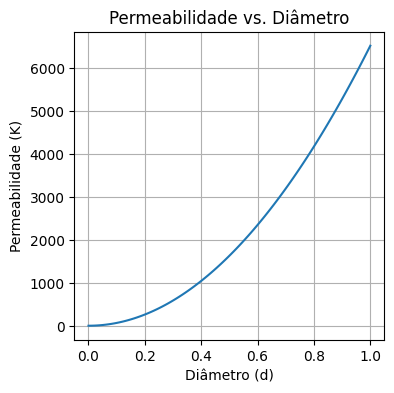

In [6]:
### Gerar o gráfico da permeabilidade pelo diâmetro

d = np.linspace(0, 1, 100)
K_d_values = (phi**3 * d**2) / (61.2 * (1 - phi)**2)
K_darcy = K_d_values * 1.013e6

plt.figure(figsize=(4, 4))
plt.plot(d, K_darcy)
plt.xlabel('Diâmetro (d)')
plt.ylabel('Permeabilidade (K)')
plt.title('Permeabilidade vs. Diâmetro')
plt.grid(True)
plt.show()

In [7]:
### Questão 2

# Dados:
R = 10e-6
L = 100e-6
mu = 1e-2
Pent = 1000
Psai = 0

In [8]:
# Condutância igual em todos os capilares

G = np.full(11, np.pi * R**4 / (8*mu*L))

In [27]:
# Matriz de incidência C (7 nós x 11 ramos)

ramos = [(1,2), (1,3), (1,4), (3,4), (2,5), (3,5), (3,6), (4,6), (5,6), (5,7), (6,7)]
C = np.zeros((7,11))

for k, (i,j) in enumerate(ramos):
    C[i-1,k] = 1     # ramo sai do nó i
    C[j-1,k] = -1    # ramo chega no nó j

# print(C)

A = C @ np.diag(G) @ C.T

### Sistema 5x5 para P2, ..., P6 (P1 e P7 conhecidas)
internos = [1,2,3,4,5]
contorno = [0,6]

A_red = A[np.ix_(internos, internos)]
b_red = -A[np.ix_(internos, contorno)] @ np.array([Pent, Psai])

P = np.zeros(7)
P[0], P[6] = Pent, Psai
P[internos] = np.linalg.solve(A_red, b_red)

### Vazão em cada capilar e vazão total
Q = G * (C.T @ P)
Q_T = Q[0] + Q[1] +Q[2]

Q_sai = Q[9] + Q[10]
print('')
print('Vazão em cada capilar:')
for i in range(11):
    print('Q', i+1, '=', Q[i], 'm^3/s')

print('')
print('Pressão em cada nó:')
for i in range(7):
    print('P', i+1, '=', P[i], 'Pa')

print("\nVazão total:")
print(f"Q_T = {Q_T:.6e} m³/s")


Vazão em cada capilar:
Q 1 = 1.061348869456011e-12 m^3/s
Q 2 = 1.3585265529036944e-12 m^3/s
Q 3 = 1.1674837564016125e-12 m^3/s
Q 4 = -1.91042796502082e-13 m^3/s
Q 5 = 1.0613488694560114e-12 m^3/s
Q 6 = 7.64171186008328e-13 m^3/s
Q 7 = 7.853981633974484e-13 m^3/s
Q 8 = 9.764409598995303e-13 m^3/s
Q 9 = 2.1226977389120273e-14 m^3/s
Q 10 = 1.8042930780752194e-12 m^3/s
Q 11 = 1.783066100686099e-12 m^3/s

Pressão em cada nó:
P 1 = 1000.0 Pa
P 2 = 729.7297297297298 Pa
P 3 = 654.0540540540541 Pa
P 4 = 702.7027027027027 Pa
P 5 = 459.4594594594595 Pa
P 6 = 454.05405405405406 Pa
P 7 = 0.0 Pa

Vazão total:
Q_T = 3.587359e-12 m³/s
